In [ ]:
# import modules
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import sxs
import scri

from kick_asym import *
plt.style.use("../MATPLOTLIB_RCPARAMS.sty")

### Useful functions

In [2]:
def h_copr_from_sxs(sxs_id):

    # load sxs waveform object with truncation of junk and time shift
    sxs_bbh = sxs.load(sxs_id)
    wf = sxs_bbh.h
    time = wf.t 
    t_peak = wf.max_norm_time()
    t_ref = sxs_bbh.metadata.reference_time 
    idx_ref = wf.index_closest_to(t_ref) 
    wf = wf[idx_ref:]
    time = time[idx_ref:] - t_peak

    # frame transformation and mode dict building
    wf_copr = wf.to_coprecessing_frame()
    data_copr = wf_copr.data.T 
    mode_list = [(ell,m) for ell in range(wf.ell_min, wf.ell_max + 1) for m in range(-ell,ell+1)]
    h_copr = dict(zip(mode_list, data_copr))

    return time, h_copr 


# ---------------------------------------------------------------------------------------------------------


def dPzdt_from_scri(h, time, ell_max):
    '''
    Computes the momentum flux in z-direction from scri.WaveformModes
    h:       mode dictionary with (l, m) tuples as keys (dict)
    time:    time array (np.array)
    l_max:   maximum l-mode (int)
    '''

    data = list(h.values())
    data = np.array(data).T

    waveform_modes = scri.WaveformModes(
                        dataType=scri.h,
                        t=time,
                        data=data,
                        ell_min=2,
                        ell_max=ell_max,
                        frameType=scri.Coprecessing,
                        r_is_scaled_out=True,
                        m_is_scaled_out=True
                        ) 

    momentum_flux = waveform_modes.momentum_flux()
    dPzdt = momentum_flux[:,2]

    return dPzdt 


# ---------------------------------------------------------------------------------------------------------


def h_dict_without_dom_asym(h, time, ell_min, ell_max):

    mode_list = [(ell,m) for ell in range(ell_min, ell_max+1) for m in range(-ell, ell+1)]
    h_22_plus = h_plus(h, time, 2, 2)
    h_symmetrized = h.copy() 
    for mode in mode_list:
        if mode == (2,2) or mode==(2,-2):
            h_symmetrized[mode] = h_22_plus
        else:
            continue
        
    return h_symmetrized 


# ---------------------------------------------------------------------------------------------------------


def h_dict_without_subdom_asym(h, time, ell_min, ell_max):

    mode_list = [(ell,m) for ell in range(ell_min, ell_max+1) for m in range(-ell, ell+1)]
    h_symmetrized = h.copy() 
    for mode in mode_list:
        if mode == (2,2) or mode==(2,-2):
            continue
        else:
            l, m = mode
            h_lm_plus = h_plus(h, time, l, m)
            h_symmetrized[mode] = h_lm_plus
        
    return h_symmetrized

### Get two configurations

In [ ]:
# configuration beta
sxs_id_beta = 'SXS:BBH:1941' 
time_beta, h_copr_beta = h_copr_from_sxs(sxs_id_beta) 
h_copr_22_sym_beta = h_dict_without_dom_asym(h_copr_beta, time_beta, 2, 8)
h_copr_lm_sym_beta = h_dict_without_subdom_asym(h_copr_beta, time_beta, 2, 8)

# cumlative trapezoid integration
dPzdt_beta = dPzdt_from_scri(h_copr_beta, time_beta, 8)
dPzdt_22_sym_beta = dPzdt_from_scri(h_copr_22_sym_beta, time_beta, 8)
dPzdt_lm_sym_beta = dPzdt_from_scri(h_copr_lm_sym_beta, time_beta, 8)
Pz_beta = cumulative_trapezoid(dPzdt_beta, time_beta, initial=0)
Pz_22_sym_beta = cumulative_trapezoid(dPzdt_22_sym_beta, time_beta, initial=0)
Pz_lm_sym_beta = cumulative_trapezoid(dPzdt_lm_sym_beta, time_beta, initial=0)

# alpha, beta, gamma, delta, psi decomposition
alpha_dict_beta, beta_dict_beta, gamma_dict_beta, delta_dict_beta, psi_dict_beta = abcdp_dicts(h_copr_beta, time_beta, 8)
values_list_beta = []
for key in alpha_dict_beta:
    values_list_beta.append(('alpha', key, simpson(alpha_dict_beta[key])))
for key in beta_dict_beta:
    values_list_beta.append(('beta', key, simpson(beta_dict_beta[key])))
for key in gamma_dict_beta:
    values_list_beta.append(('gamma', key, simpson(gamma_dict_beta[key])))
for key in delta_dict_beta:
    values_list_beta.append(('delta', key, simpson(delta_dict_beta[key])))
sorted_values_beta = sorted(values_list_beta, key=lambda x: x[2], reverse=True)

# top beta values
top = 3
first_entries_beta = sorted_values_beta[:(top)]
top_keys_beta = [key for _, key, _ in sorted_values_beta[:(top)]]
first_entries_beta

Loading SXS simulations using latest tag 'v3.0.0', published at 2025-05-14T18:17:30Z.


[('beta', (2, 2, 2, 2), 0.0785318590076318),
 ('beta', (3, 3, 3, 3), 0.04108837234152403),
 ('beta', (4, 4, 4, 4), 0.013753923732100722)]

In [4]:
# configuration psi
sxs_id_psi = 'SXS:BBH:3392' 
time_psi, h_copr_psi = h_copr_from_sxs(sxs_id_psi) 
h_copr_22_sym_psi = h_dict_without_dom_asym(h_copr_psi, time_psi, 2, 8)
h_copr_lm_sym_psi = h_dict_without_subdom_asym(h_copr_psi, time_psi, 2, 8)

# cumlative trapezoid integration
dPzdt_psi = dPzdt_from_scri(h_copr_psi, time_psi, 8)
dPzdt_22_sym_psi = dPzdt_from_scri(h_copr_22_sym_psi, time_psi, 8)
dPzdt_lm_sym_psi = dPzdt_from_scri(h_copr_lm_sym_psi, time_psi, 8)
Pz_psi = cumulative_trapezoid(dPzdt_psi, time_psi, initial=0)
Pz_22_sym_psi = cumulative_trapezoid(dPzdt_22_sym_psi, time_psi, initial=0)
Pz_lm_sym_psi = cumulative_trapezoid(dPzdt_lm_sym_psi, time_psi, initial=0)

# alpha, beta, gamma, delta, psi decomposition
alpha_dict_psi, beta_dict_psi, gamma_dict_psi, delta_dict_psi, psi_dict_psi = abcdp_dicts(h_copr_psi, time_psi, 8)
values_list_psi = []
for key in alpha_dict_psi:
    values_list_psi.append(('alpha', key, simpson(alpha_dict_psi[key])))
for key in beta_dict_psi:
    values_list_psi.append(('beta', key, simpson(beta_dict_psi[key])))
for key in gamma_dict_psi:
    values_list_psi.append(('gamma', key, simpson(gamma_dict_psi[key])))
for key in delta_dict_psi:
    values_list_psi.append(('delta', key, simpson(delta_dict_psi[key])))
sorted_values_psi = sorted(values_list_psi, key=lambda x: x[2], reverse=True)

idx_beta_top1_max = np.argmax(beta_dict_beta[top_keys_beta[0]])

# top beta values
top = 3
first_entries_psi = sorted_values_psi[:(top)]
top_keys_psi = [key for _, key, _ in sorted_values_psi[:(top)]]
idx_beta_top1_max = np.argmax(beta_dict_beta[top_keys_beta[0]])
idx_beta_top2_max = np.argmax(beta_dict_beta[top_keys_beta[1]])
first_entries_psi

[('beta', (2, 2, 2, 2), 0.6789895131184439),
 ('beta', (3, 3, 3, 3), 0.05196030971133618),
 ('beta', (3, 2, 2, 2), 0.04949213679673492)]

### Paper Plot

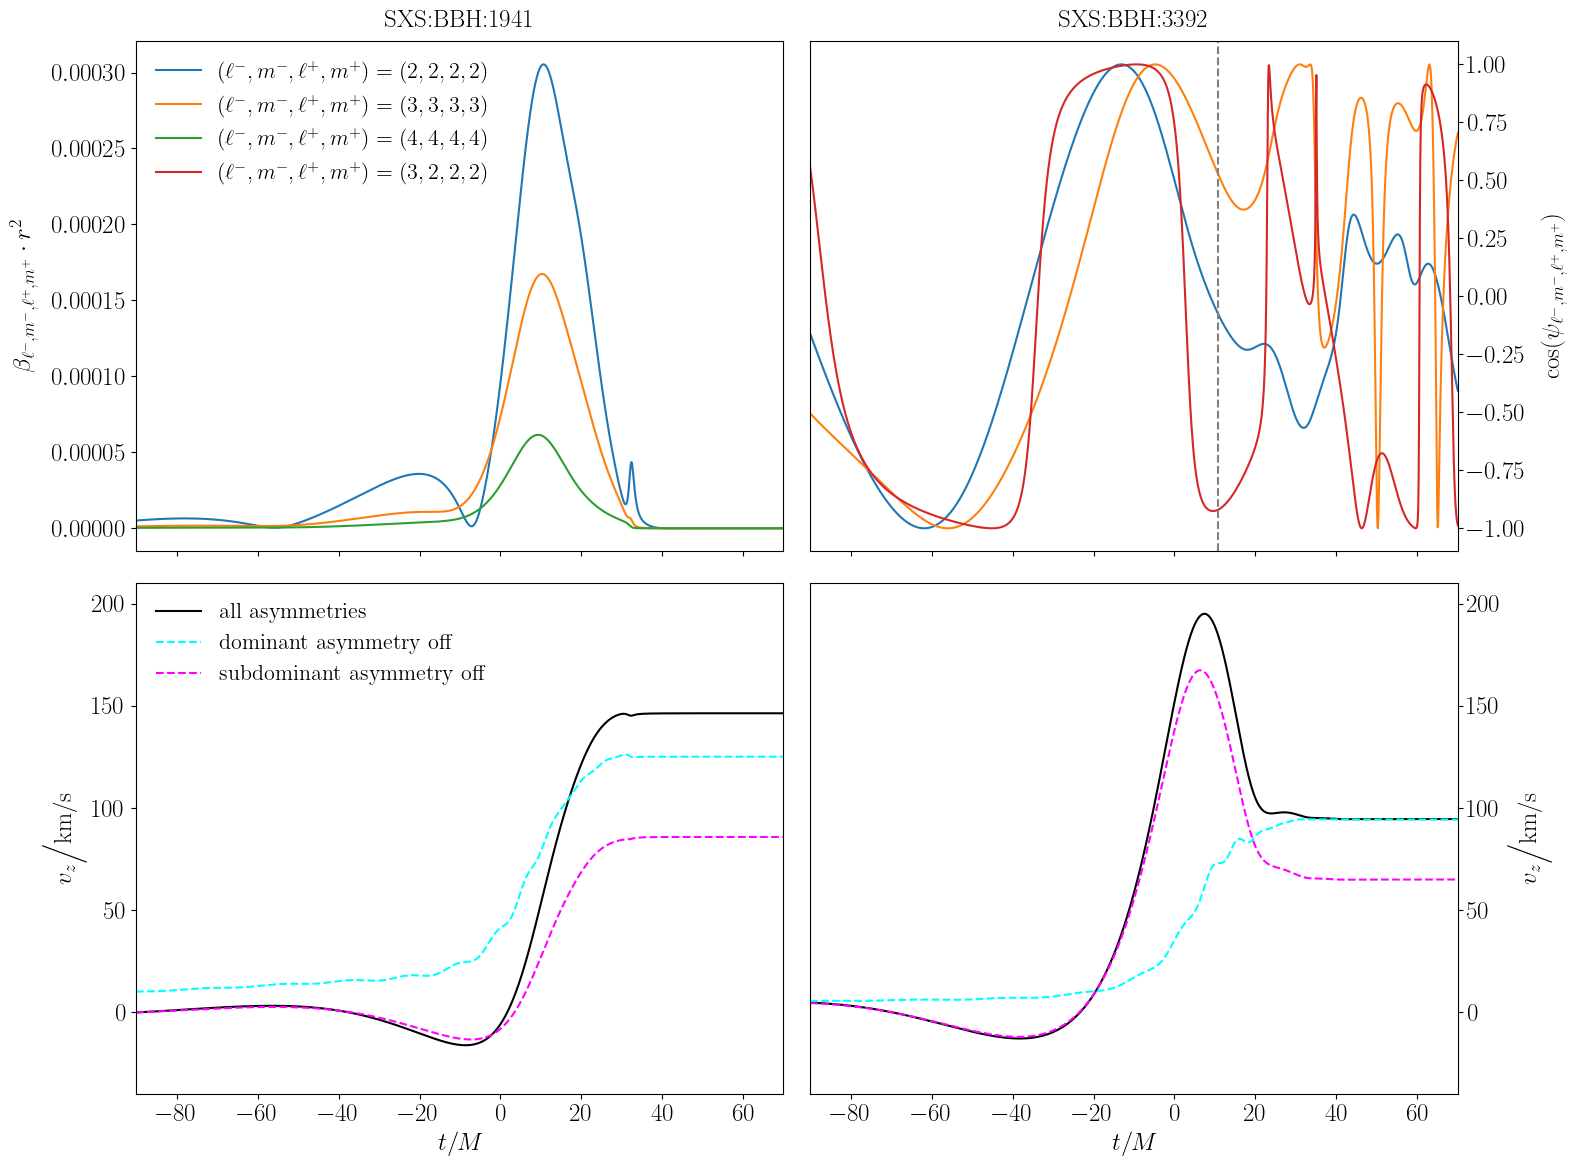

In [5]:
fig = plt.figure(figsize=(16,12))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

xlims = -90, 70
ylims = -40, 210
c =  299792458e-3    #speed of light in km/s  

for key in top_keys_beta:
    label = r"$(\ell^-,m^-,\ell^+,m^+)=(%d,%d,%d,%d)$" % key
    ax1.plot(time_beta, beta_dict_beta[key], label=label)


ax2.plot(time_psi, np.cos(psi_dict_psi[top_keys_psi[0]]))
ax2.plot(time_psi, np.cos(psi_dict_psi[top_keys_psi[1]]))
ax2.plot(time_psi, np.cos(psi_dict_psi[top_keys_psi[2]]), label=r"$(\ell^-,m^-,\ell^+,m^+)=(%d,%d,%d,%d)$" % top_keys_psi[2], 
         color='tab:red')


ax3.plot(time_beta, Pz_beta*c, label=r'all asymmetries', color='black')
ax3.plot(time_beta, Pz_22_sym_beta*c, '--', label=r'dominant asymmetry off', color='cyan')
ax3.plot(time_beta, Pz_lm_sym_beta*c, '--', label=r'subdominant asymmetry off', color='magenta')

ax4.plot(time_psi, Pz_psi*c, color='black')
ax4.plot(time_psi, Pz_22_sym_psi*c, '--', color='cyan')
ax4.plot(time_psi, Pz_lm_sym_psi*c, '--', color='magenta')


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2
ax1.legend(handles, labels, loc='upper left', ncol=1, frameon=False,
           bbox_to_anchor=(0, 1), fontsize=16)
ax1.set_xlim(xlims)
ax1.set_ylabel(r'$\beta_{\ell^-,m^-,\ell^+,m^+} \cdot r^2$', labelpad=10)
ax1.set_title(sxs_id_beta, pad=10)
ax1.tick_params('x', labelbottom=False)


ax2.set_xlim(xlims)
ax2.set_ylabel(r'$\cos(\psi_{\ell^-,m^-,\ell^+,m^+})$', labelpad=10)
ax2.yaxis.set_label_position('right')
ax2.yaxis.tick_right()
ax2.set_title(sxs_id_psi, pad=10)
ax2.tick_params('x', labelbottom=False)
ax2.axvline(time_beta[idx_beta_top1_max], linestyle='--', color='grey')

ax3.legend(loc='upper left', ncol=1, frameon=False, bbox_to_anchor=(0, 1), fontsize=16)
ax3.set_xlim(xlims)
ax3.set_ylim(ylims)
ax3.set_xlabel(r'$t/M$')
ax3.set_ylabel(r'$v_z\Big/ \text{km/s}$')

ax4.set_xlim(xlims)
ax4.set_ylim(ylims)
ax4.set_xlabel(r'$t/M$')
ax4.set_ylabel(r'$v_z\Big/ \text{km/s}$')
ax4.yaxis.set_label_position('right')
ax4.yaxis.tick_right()

plt.tight_layout()
# plt.savefig('subdom_kick.pdf')
plt.show()
